# 07 — Explainable Analysis: What the System Does, Week by Week

The aggregate result — a two-year out-of-sample return of $+56.8\%$ at a Sharpe of $2.02$ —
says *that* the fund of agents works, not *how*. This notebook opens the black box on a handful
of individual weeks. For each one it shows learned-agent probabilities, rule-agent directional
signals, per-agent entries and exits, the fund's net exposure, the long/short/flat capital split,
and the realised fund-versus-BTC return over those seven days.

The weeks are not cherry-picked by eye. They are chosen by transparent rules from
`_xai_core.select_weeks`:

- **Defence** — the single worst intra-week BTC drawdown in the whole out-of-sample window.
- **Trend** — among weeks where BTC rallies more than $+5\%$, the one where the fund gains most.
- **Divergence** — BTC clearly down (worse than $-4\%$ on the week) while the fund still closes
  *up*. This is retained as a supporting stress case.

All series are loaded from the committed artifacts and the positions are rebuilt with the same
`bracket_run` engine used to produce the headline numbers, so nothing here can disagree with the
results chapter.

In [1]:
import sys
sys.path.insert(0, ".")
import pandas as pd
import _xai_core as x

panel, agents, fund_eq, weights = x.load_everything()
wt = x.weekly_table(panel, fund_eq)
sel = x.select_weeks(wt)
pd.DataFrame({k: wt.loc[v, ["btc_ret", "fund_ret", "divergence", "btc_maxdd"]]
              for k, v in sel.items()}).T.style.format("{:.1%}")

,btc_ret,fund_ret,divergence,btc_maxdd
divergence,-13.5%,0.7%,14.2%,-14.1%
trend,6.9%,4.9%,-2.1%,-6.9%
defence,-9.5%,4.3%,13.8%,-20.4%


## Main case: defence week — surviving the worst sell-off

This is the most important case-study week. Bitcoin suffers the worst intra-week drawdown in the
hold-out, yet the fund finishes meaningfully positive. The mechanism is not a single heroic short:
the book is a mix of long, short, and flat agents, and the allocator keeps a large fraction of
capital inactive while selectively funding agents whose brackets are working.

Panel A overlays BTC candles with the fund's net directional exposure (green shading = net long,
red = net short) and price-level trade markers. Panel B shows how the coordinator's capital is
split across agents that are currently long, short, or flat/cash. Panel C is the event ledger:
each row is one learned agent, so it is clear which agent entered, took profit, hit stop-loss, or
exited by time. Panel D shows learned-agent $P(\text{up})$ traces, Panel E shows the three
rule-agent directional signals, and Panel F compares the MAS fund, BTC, and each individual agent's
cumulative return over the same seven days.

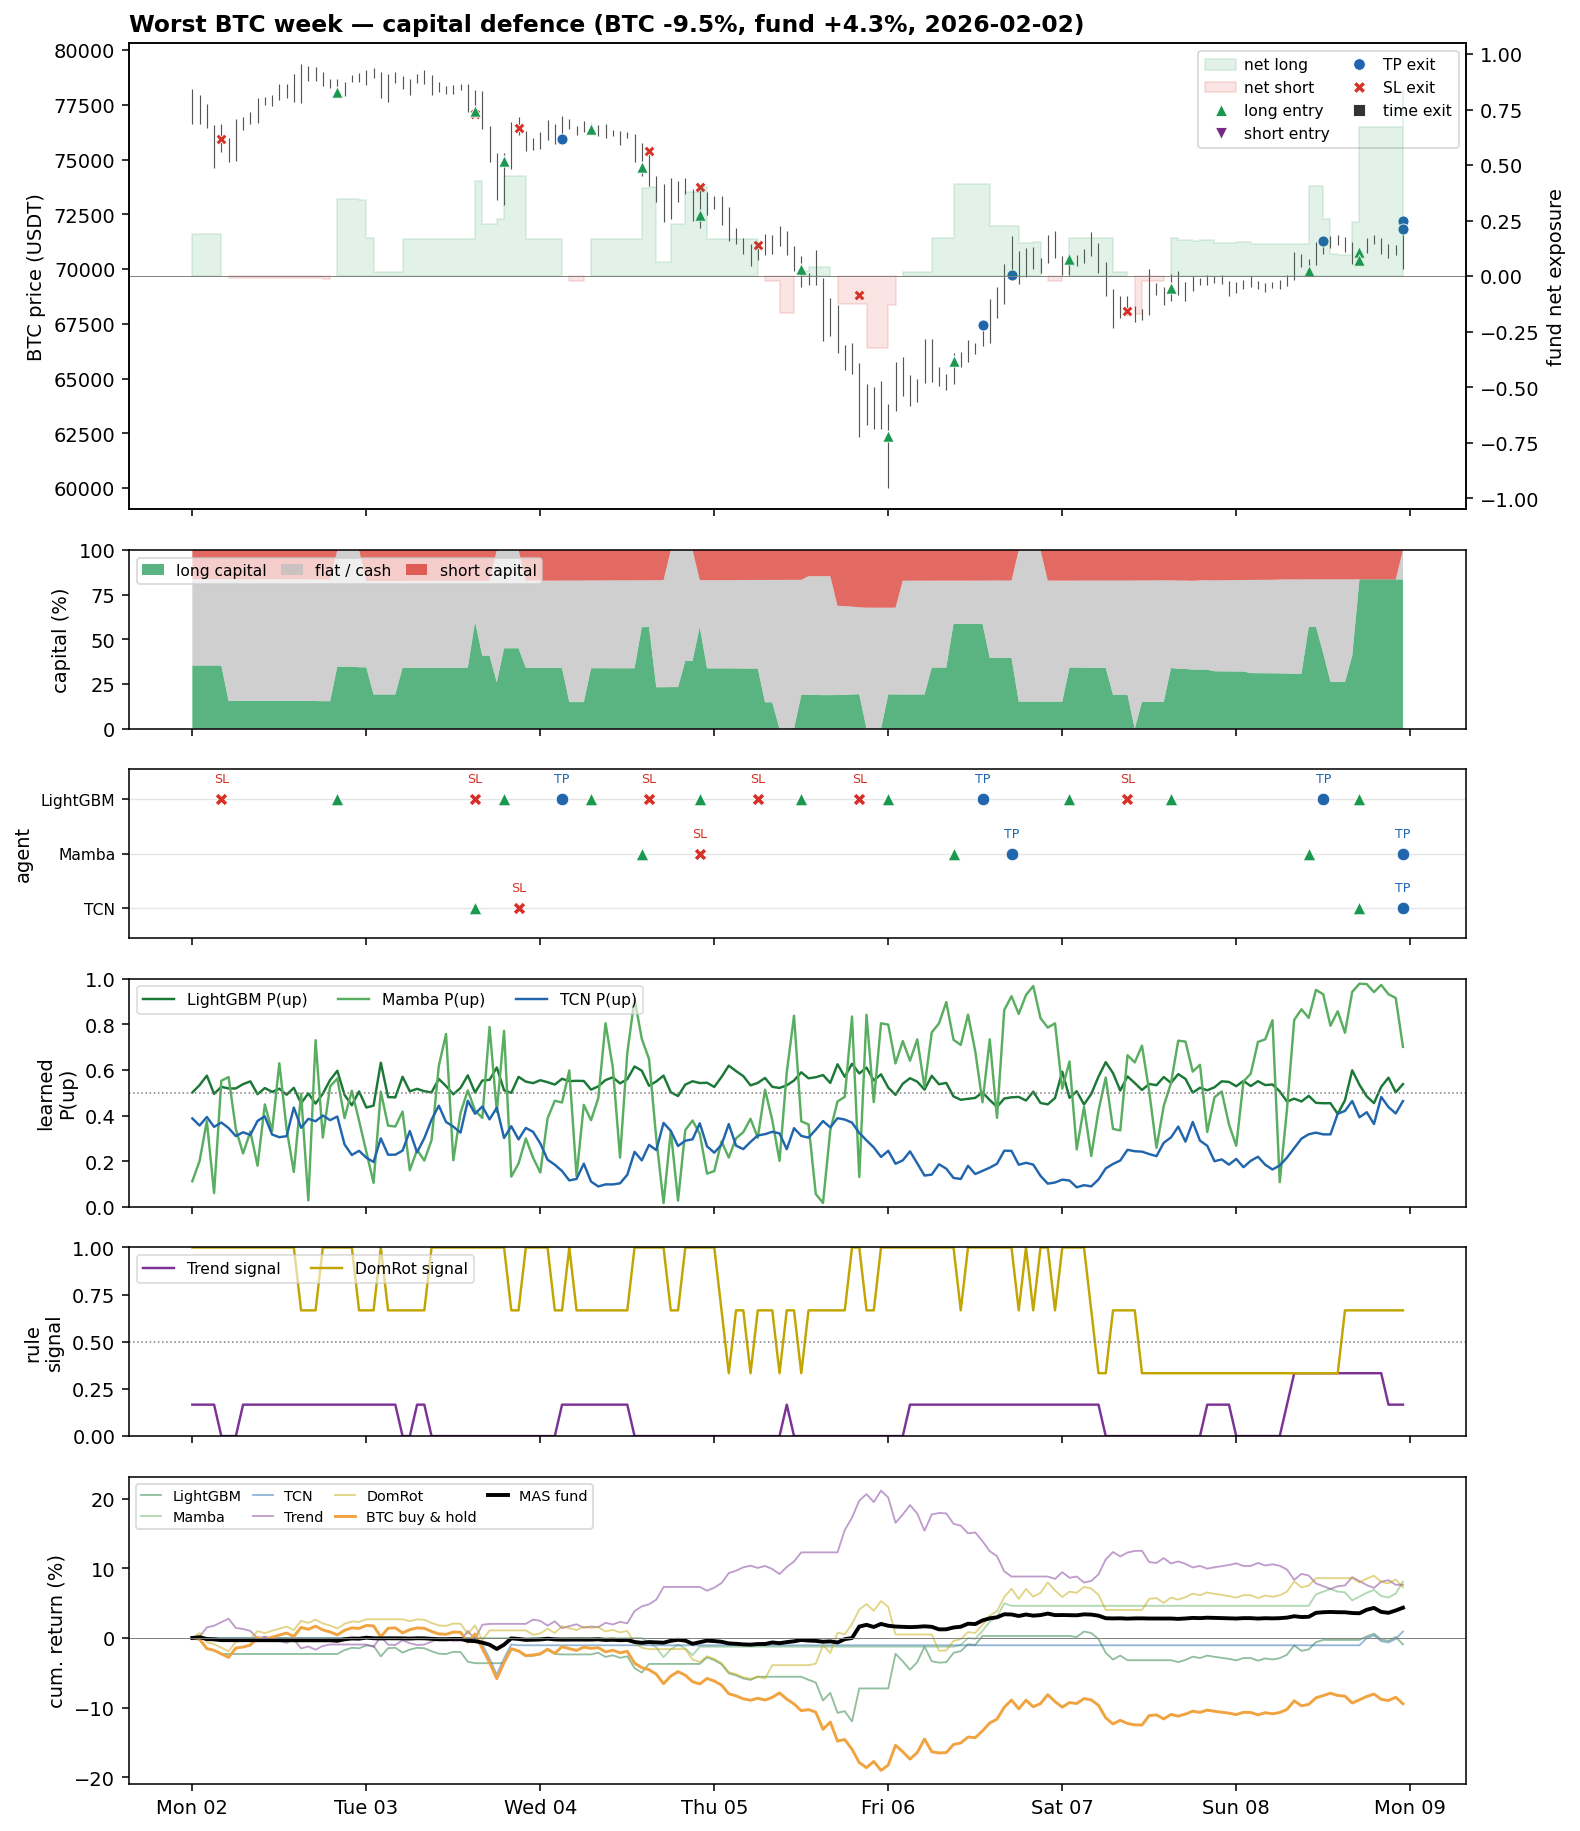

In [2]:
wk = sel["defence"]; r = wt.loc[wk]
x.plot_case_week(wk, panel, agents, fund_eq, weights,
                 f"Worst BTC week — capital defence (BTC {r.btc_ret:+.1%}, fund {r.fund_ret:+.1%}, {wk.date()})",
                 "02_case_defence.png")
from IPython.display import Image
Image(str(x.OUT / "02_case_defence.png"))

In [3]:
# Per-agent activity over the defence week: hours long / short / flat and mean signal.
import numpy as np
wkmask = (panel.index >= wk) & (panel.index < wk + pd.Timedelta(days=7))
rows = []
for a in weights.columns:
    pos = agents[a].position[wkmask]
    rows.append({"agent": a,
                 "hours_long": int((pos > 0).sum()),
                 "hours_short": int((pos < 0).sum()),
                 "hours_flat": int((pos == 0).sum()),
                 "mean_P_up": round(float(panel.loc[wkmask, a].mean()), 3)})
pd.DataFrame(rows).set_index("agent")

,hours_long,hours_short,hours_flat,mean_P_up
agent,,,,
lgbm,113,0,55,0.528
mamba,32,0,136,0.510
tcn,14,0,154,0.272
trend,0,147,21,0.099
dominance_rotation,127,13,28,0.746


Read the activity table together with Panels B, C and F. PatchTST is the only **short-only** final
agent; Mamba is the only **long-only** final agent; LightGBM, TCN and the three retained rule agents
can trade both sides, though their realised tilts differ. During the sell-off, PatchTST and the
trend rule repeatedly contribute short-side gains, while long-biased agents either stop out quickly
or remain flat. The capital-state panel explains why the fund does not behave like a leveraged
short: a large grey band remains flat/cash, and some capital is still assigned to long agents.
The result is a moderated response to a violent move rather than an all-in directional bet.

## Counter-case: trend week — participating, but not chasing

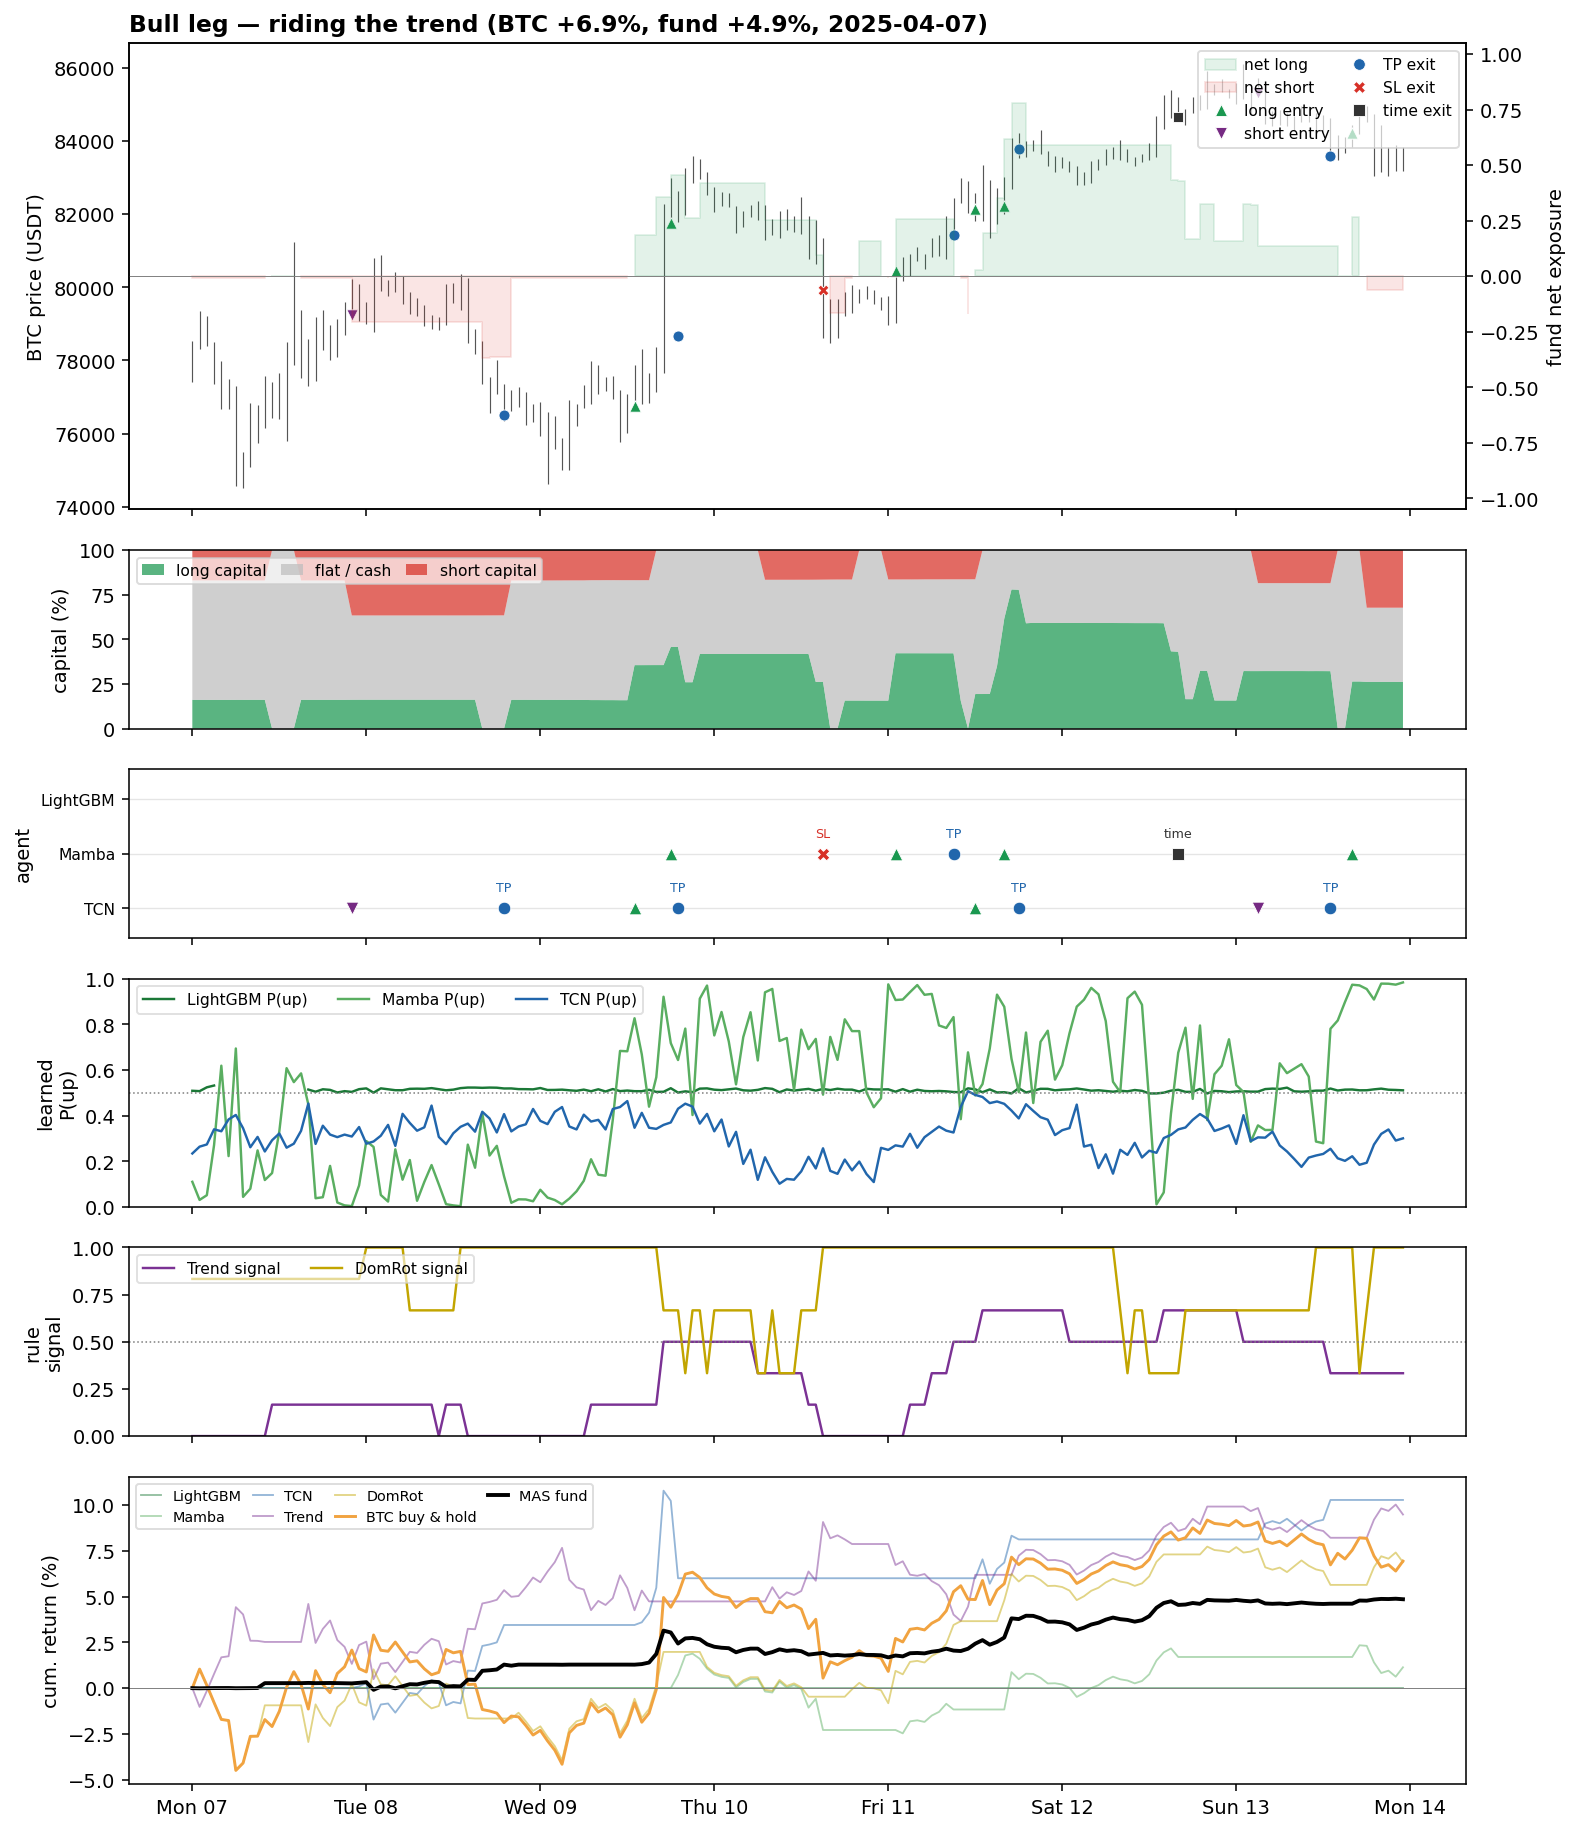

In [4]:
wk2 = sel["trend"]; r2 = wt.loc[wk2]
x.plot_case_week(wk2, panel, agents, fund_eq, weights,
                 f"Bull leg — riding the trend (BTC {r2.btc_ret:+.1%}, fund {r2.fund_ret:+.1%}, {wk2.date()})",
                 "03_case_trend.png")
Image(str(x.OUT / "03_case_trend.png"))

The trend week is the honest counter-case. BTC rallies strongly, and the fund participates, but it
does not match buy-and-hold. That is expected: PatchTST is short-only, several agents are allowed to
trade both sides, and cooldown plus ATR exits prevent the whole book from instantly becoming fully
long. The same machinery that softens a large drawdown also softens a vertical rally. This is not a
defect in the case study; it is the price of building for drawdown control rather than maximum beta.

## Supporting divergence week — BTC falls, the fund rises

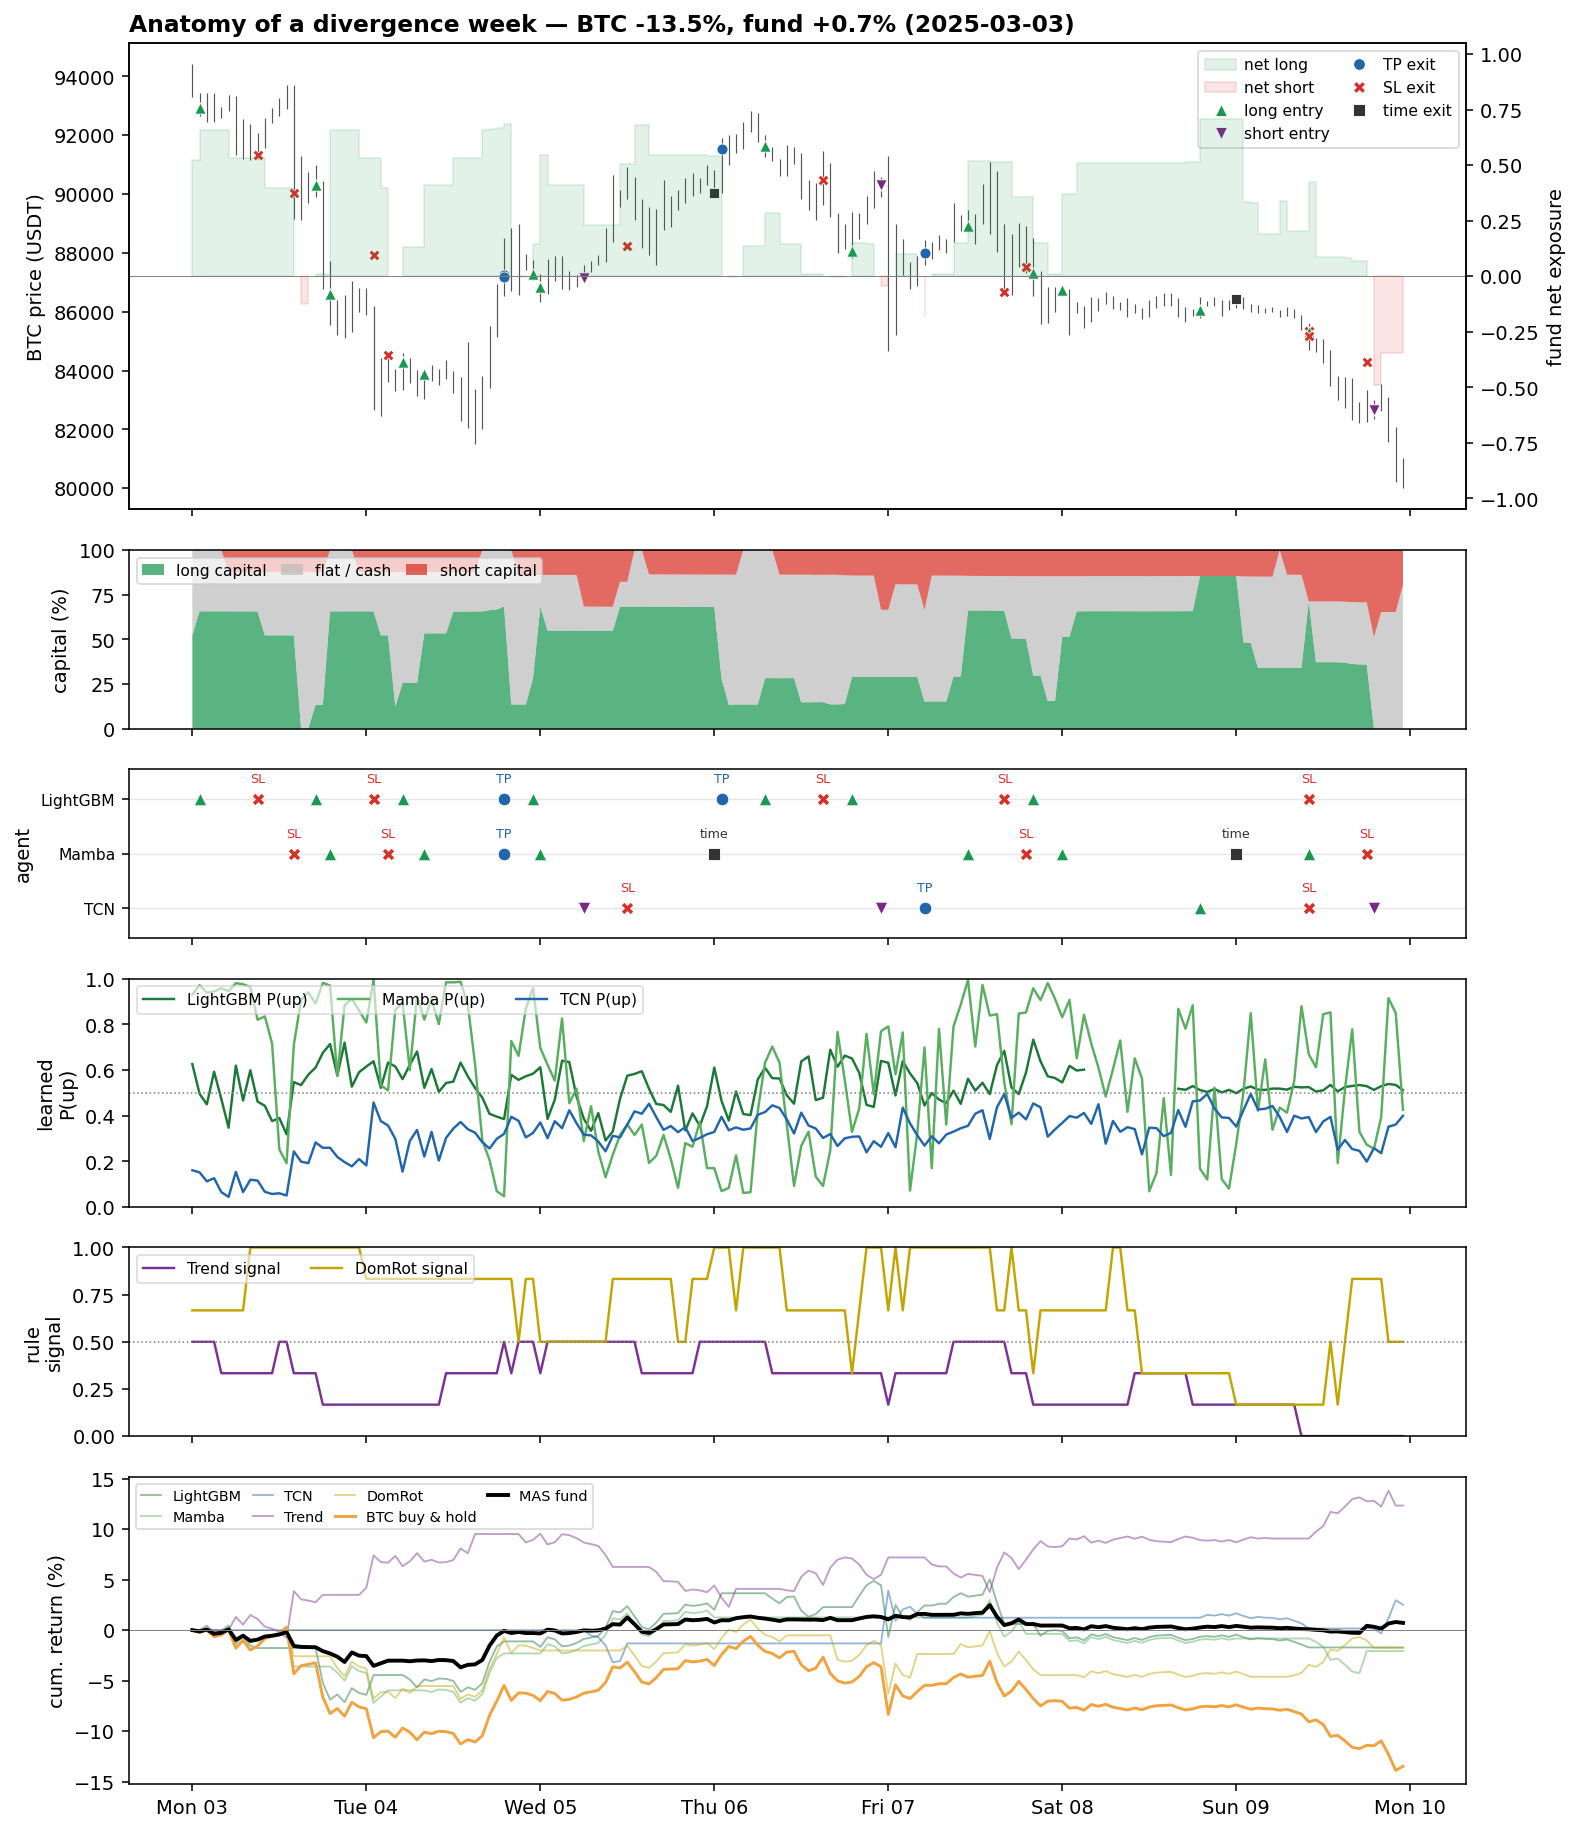

In [5]:
wk3 = sel["divergence"]; r3 = wt.loc[wk3]
x.plot_case_week(wk3, panel, agents, fund_eq, weights,
                 f"Anatomy of a divergence week — BTC {r3.btc_ret:+.1%}, fund {r3.fund_ret:+.1%} ({wk3.date()})",
                 "01_case_divergence.png")
Image(str(x.OUT / "01_case_divergence.png"))

The divergence week is a supporting stress example: BTC closes materially down while the fund closes
up. It repeats the same mechanism as the defence case but with a less extreme path: the book is not
a single forecast, but a capital allocation across agents with different directional mandates,
signals and cooldown states.

## What carries into the thesis

Across these weeks the same mechanism appears. Heterogeneous directional exposure — one long-only
agent, one short-only agent, and several two-sided agents reading different inputs — means the roster
is rarely all on the same side of the market. The volatility-aware allocator then decides how much
capital is long, short, or inactive. The result is a return stream whose defining feature is
moderation in high-volatility moves: it dampens large drops, but also gives up part of large rallies.